# World Cup 2026 — probabilistic score forecasting

**Author:** gclaus · **Package:** [`wcforecast`](https://github.com/CodeWithGreg/wc26-forecast) · compiled on tournament opening day (2026-06-11)

This notebook showcases the full pipeline:

1. fit the **Dixon-Coles + LightGBM ensemble** on 37k international matches,
2. inspect the **leave-one-tournament-out backtest** (10 majors, 535 matches) and its **calibration**,
3. forecast the **72 scheduled group games** with uncertainty,
4. explain a forecast with **SHAP**,
5. simulate the tournament (championship odds, and a forecast of **the final — before we know who plays it**),
6. derive **Mon Petit Prono optimal picks**.

Methodological background and the survey of prior art (Maher → Dixon-Coles → Karlis-Ntzoufras → Groll/Zeileis hybrids) live in [`BENCHMARK.md`](../BENCHMARK.md).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

from wcforecast.data import load_results, load_group_fixtures
from wcforecast.predictor import MatchPredictor

results = load_results()
print(f"{len(results):,} played internationals, {results['date'].min():%Y} → {results['date'].max():%Y-%m-%d}")

37,312 played internationals, 1980 → 2026-06-10


## 1 — Fit the ensemble

Two complementary scoreline models, combined by a log-linear pool (weight fit out-of-sample in the backtest):

* **Dixon-Coles** bivariate Poisson with exponential time decay (half-life 3y), ridge-MAP abilities and a **Laplace posterior** → epistemic uncertainty on every team's attack/defence;
* **LightGBM Poisson** on leak-free features (Elo, rolling form, rest, venue, importance), **Bayesian-bootstrap bagged** → epistemic spread of λ.

In [2]:
pred = MatchPredictor.fit(results)   # ~15 s
print(f"pool weight on Dixon-Coles: {pred.weight_dc:.2f}")

[fit] Dixon-Coles on 37312 matches…
[fit] ρ = -0.0413 (±0.0223), home adv γ = +0.267
[fit] LightGBM Poisson bag…


pool weight on Dixon-Coles: 0.60


In [3]:
# Posterior team abilities (Dixon-Coles): attack + defence ± 1 sd
pred.dc.abilities().head(12).round(3)

,team,attack,attack_sd,defence,defence_sd,strength
0,Argentina,0.967,0.106,1.137,0.170,2.105
1,Brazil,1.015,0.112,0.889,0.149,1.904
2,Spain,1.019,0.099,0.870,0.147,1.889
3,England,0.796,0.104,0.950,0.160,1.746
4,Colombia,0.854,0.119,0.829,0.146,1.682
5,Portugal,0.891,0.101,0.778,0.146,1.669
6,France,0.863,0.103,0.770,0.140,1.633
7,Morocco,0.604,0.099,1.023,0.167,1.627
8,Japan,0.840,0.099,0.776,0.153,1.616
9,Belgium,0.855,0.102,0.677,0.145,1.533


## 2 — Does it actually forecast? The backtest

Every model is refit with data **strictly before** each of the 10 major tournaments (WC 2006–2022, EURO 2008–2024) and scored on that tournament — the honest pre-tournament setting. Primary metric: **1X2 log-loss** (see BENCHMARK §6 for why), with RPS for literature comparability, exact-score log-loss and Poisson deviance for the goal head, and coverage for the predictive intervals.

In [4]:
agg = pd.read_csv("../reports/backtest_aggregate.csv")
agg.sort_values("log_loss_1x2").round(4)

,model,log_loss_1x2,rps,brier,accuracy,exact_score_ll,poisson_deviance,coverage90_total_goals
2,ensemble,0.9929,0.2052,0.5916,0.5290,2.8039,1.1366,0.9570
0,dixon_coles,0.9933,0.2050,0.5923,0.5439,2.8105,1.1459,0.9551
3,gbm,1.0052,0.2097,0.5999,0.5196,2.8241,1.1567,0.9626
1,elo_poisson,1.0144,0.2127,0.6070,0.5290,2.8314,1.1643,0.9589
4,uniform,1.0785,0.2361,0.6539,0.4112,2.9155,1.2484,0.9533


The ensemble beats the **Elo-only Poisson baseline** (the strong simple model most public predictors amount to) on *every* proper score, and the uniform floor by a wide margin. Note the classic pattern from the literature: covariates barely move 1X2 log-loss vs Dixon-Coles alone, but consistently sharpen the **full scoreline distribution** (exact-score LL, deviance). 90% intervals on total goals cover ~95% — discrete intervals over-cover by construction.

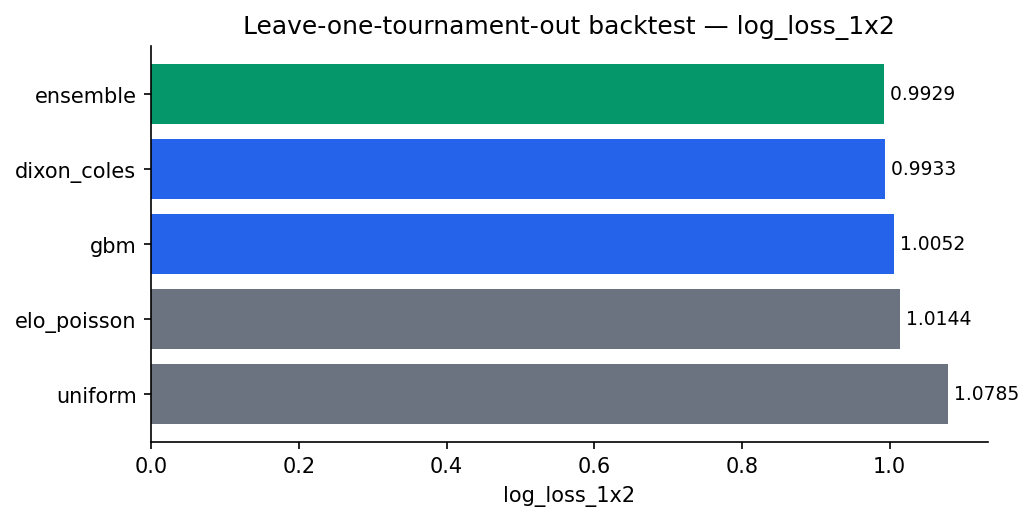

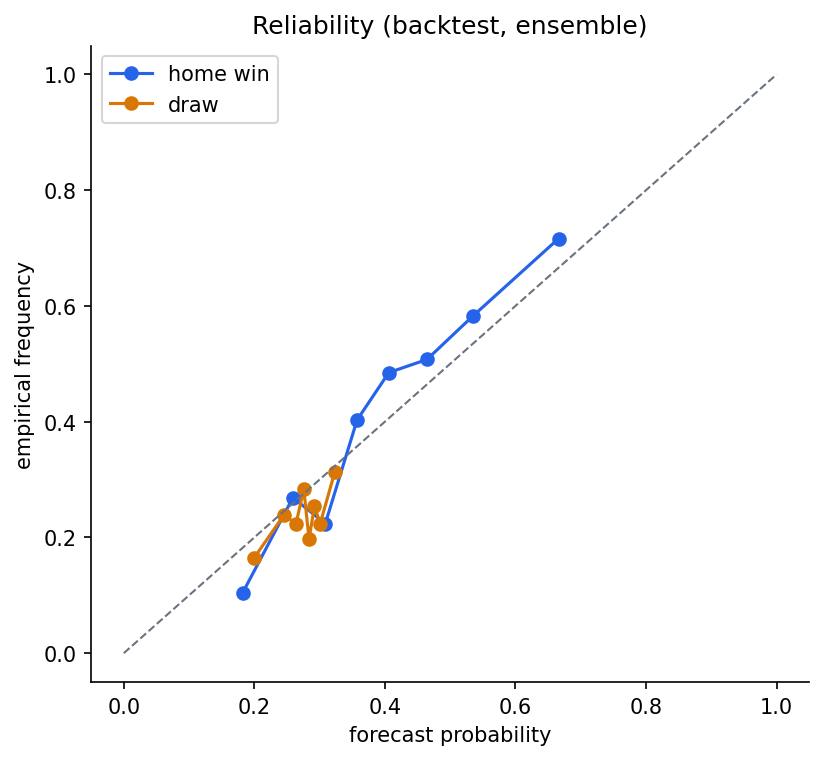

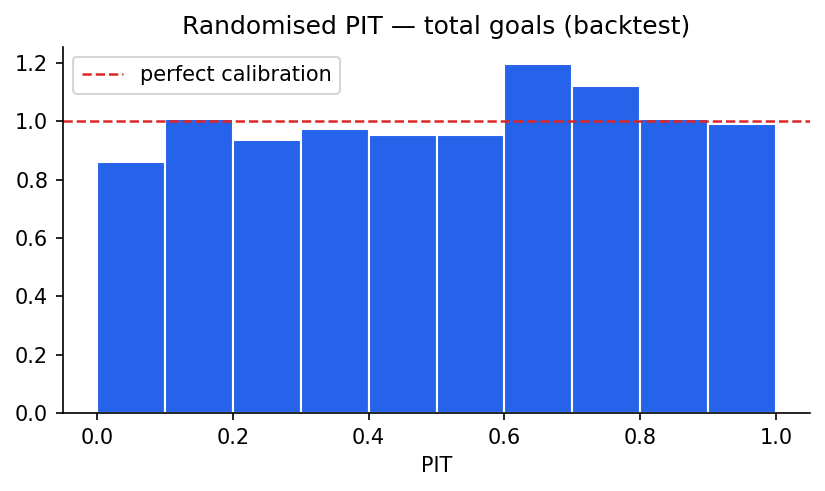

In [5]:
display(Image("../reports/figures/backtest_logloss.png"))
display(Image("../reports/figures/reliability.png"))
display(Image("../reports/figures/pit_total_goals.png"))

## 3 — Group-stage forecasts (all 72 scheduled matches)

`wcf predict fixtures` writes the full table; below, the opening days. `λ` columns are posterior-mean expected goals, the `ci90` columns are **epistemic** 90% intervals on λ (how sure the model is about the *rate*), and `goals_90` are predictive intervals on actual goals (rate + Poisson noise).

In [6]:
gp = pd.read_csv("../predictions/group_stage.csv")
gp.head(14)

,date,stage,home_team,away_team,lam_home,lam_away,lam_home_ci90,lam_away_ci90,p_home,p_draw,p_away,most_likely_score,p_most_likely,goals_home_90,goals_away_90
0,2026-06-11,group A,Mexico,South Africa,1.748,0.685,"[1.32,2.16]","[0.54,0.85]",0.6221,0.2383,0.1396,1-0,0.1491,0-4,0-2
1,2026-06-11,group A,South Korea,Czech Republic,1.353,1.190,"[1.13,1.91]","[0.83,1.49]",0.4032,0.2760,0.3207,1-1,0.1302,0-4,0-3
2,2026-06-12,group B,Canada,Bosnia and Herzegovina,1.864,0.710,"[1.38,2.70]","[0.51,0.88]",0.6350,0.2277,0.1374,1-0,0.1390,0-4,0-2
3,2026-06-12,group D,United States,Paraguay,1.436,1.049,"[1.15,1.84]","[0.76,1.26]",0.4555,0.2718,0.2726,1-1,0.1276,0-4,0-3
4,2026-06-13,group D,Australia,Turkey,1.317,1.191,"[1.03,1.95]","[0.78,1.49]",0.3900,0.2782,0.3318,1-1,0.1304,0-3,0-3
5,2026-06-13,group C,Brazil,Morocco,1.123,1.091,"[0.88,1.48]","[0.68,1.54]",0.3669,0.3017,0.3314,1-1,0.1365,0-3,0-3
6,2026-06-13,group C,Haiti,Scotland,1.198,1.452,"[0.98,1.55]","[1.18,1.93]",0.3073,0.2652,0.4275,1-1,0.1247,0-3,0-4
7,2026-06-13,group B,Qatar,Switzerland,0.804,1.989,"[0.59,1.11]","[1.66,2.51]",0.1409,0.2145,0.6446,0-2,0.1202,0-2,0-5
8,2026-06-14,group E,Germany,Curaçao,2.538,0.815,"[1.98,3.28]","[0.62,0.95]",0.7385,0.1617,0.0998,2-0,0.1101,0-5,0-3
9,2026-06-14,group E,Ivory Coast,Ecuador,0.898,1.017,"[0.56,1.25]","[0.73,1.25]",0.3011,0.3263,0.3725,0-0,0.1567,0-3,0-3


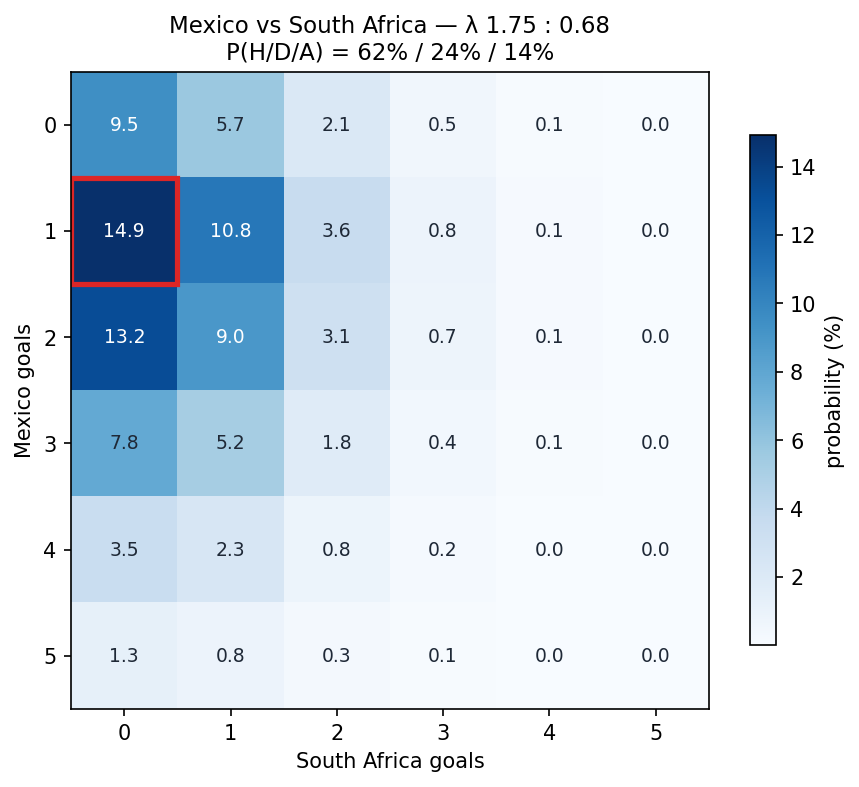

Mexico λ = 1.75, 90% epistemic CI [1.32, 2.16]


In [7]:
# the opening match, in full: scoreline heatmap + uncertainty
from wcforecast.viz import score_heatmap
f = pred.forecast("Mexico", "South Africa", neutral=False, date="2026-06-11")
score_heatmap(f, path="../reports/figures/opener_heatmap.png")
display(Image("../reports/figures/opener_heatmap.png"))
lo, hi = f.lam_interval("home")
print(f"Mexico λ = {f.lam_home:.2f}, 90% epistemic CI [{lo:.2f}, {hi:.2f}]")

## 4 — Why this forecast? SHAP contributions

SHAP values on the GBM head are additive contributions to **log λ** (multiplicative on goals). The Dixon-Coles half is interpretable by construction; together they make the whole ensemble explainable.

In [8]:
from wcforecast.explain import match_contributions
from wcforecast.features.build import to_side_view

feats = pred._fixture_features("France", "Brazil", True, None, "world_cup")
side = to_side_view(feats.assign(home_score=np.nan, away_score=np.nan), with_target=False)
match_contributions(pred.gbm, side.iloc[[0]]).head(10).round(3)

/sessions/affectionate-blissful-newton/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,value,contribution,contribution_sd
0,gf10_team,2.500,0.170,0.015
1,winrate10_team,0.800,0.086,0.017
2,ga10_opp,1.100,-0.080,0.010
3,is_away_nonneutral,0.000,0.071,0.008
4,is_home_nonneutral,0.000,-0.062,0.006
5,ga10_team,0.900,0.061,0.009
6,gf5_team,2.400,0.029,0.009
7,gf5_opp,2.600,-0.028,0.009
8,winrate10_opp,0.600,-0.024,0.008
9,elo_team,2109.304,0.021,0.017


## 5 — Tournament simulation

14,000 Monte-Carlo tournaments through the real 2026 format: 12 groups, best-thirds allocation by constraint matching, the full R32→final bracket, extra time + penalties, host venue advantage.

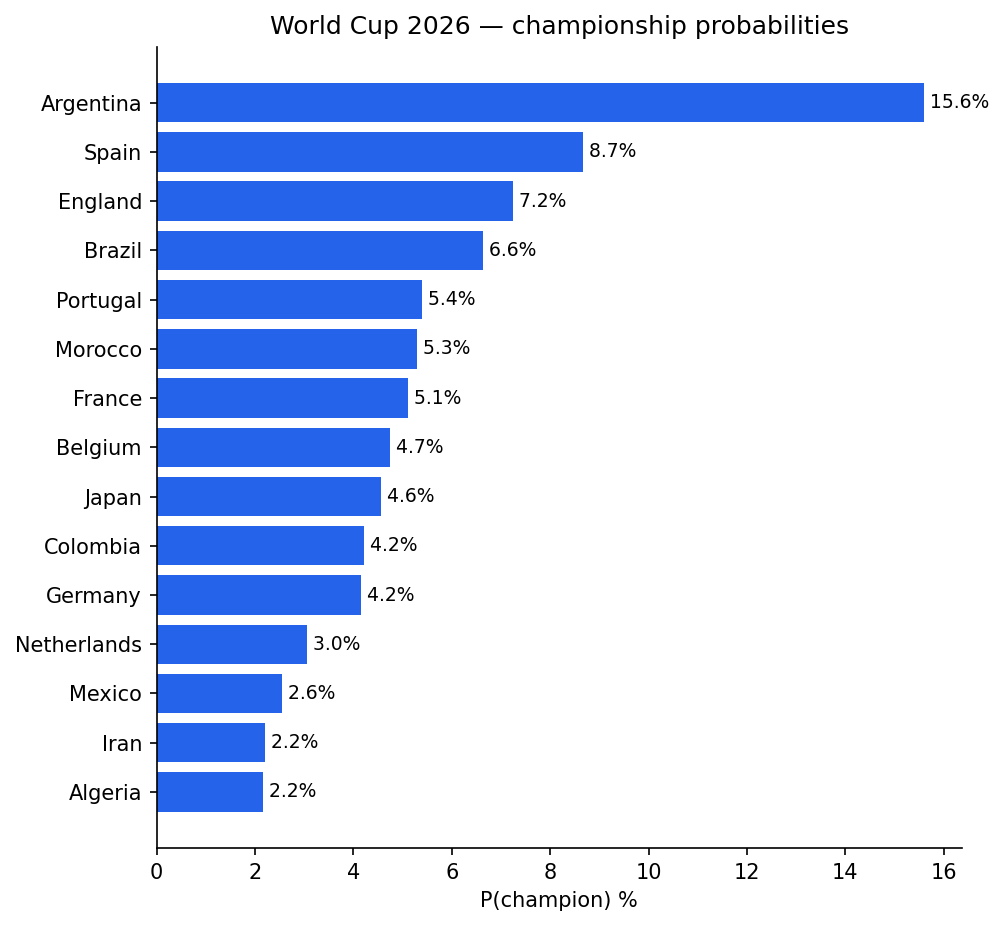

,R32,R16,QF,SF,FINAL,champion
Argentina,94.8,67.5,49.3,35.0,23.7,15.6
Spain,95.4,57.2,37.0,24.4,15.0,8.7
England,94.9,61.0,37.0,22.0,12.7,7.2
Brazil,90.3,56.2,36.5,22.5,12.2,6.6
Portugal,86.5,57.2,32.9,18.4,10.2,5.4
Morocco,87.0,51.2,32.1,18.4,9.7,5.3
France,87.2,54.9,31.7,18.1,9.8,5.1
Belgium,89.5,58.8,33.4,17.6,9.4,4.7
Japan,88.9,48.8,30.1,16.8,8.7,4.6
Colombia,84.7,53.9,29.6,16.2,8.7,4.2


In [9]:
sim_table = pd.read_csv("../predictions/simulation.csv", index_col=0)
display(Image("../reports/figures/champion_probs.png"))
(sim_table.head(12)[["R32", "R16", "QF", "SF", "FINAL", "champion"]] * 100).round(1)

### Forecasting the **final** — participants unknown

The headline trick: a forecast for bracket slot 104 (the final, July 19) *today*. The simulation gives the pairing distribution; the unconditional scoreline forecast is the pairing-weighted mixture of conditional forecasts (`wcf predict slot 104`).

In [10]:
display(pd.read_csv("../predictions/final_pairings.csv"))
pd.read_csv("../predictions/slot_forecasts.csv")

,home,away,prob
0,Spain,Argentina,0.0238
1,Belgium,Argentina,0.0119
2,Spain,England,0.0105
3,Morocco,Argentina,0.0101
4,Germany,Argentina,0.0100
5,Japan,Argentina,0.0099
6,France,Argentina,0.0094
7,Spain,Brazil,0.0090
8,Brazil,Argentina,0.0084
9,Portugal,Argentina,0.0078


,match,stage,top_pairing,p_top_pairing,lam_home_slot,lam_away_slot,p_home,p_draw,p_away,top_scores
0,104,FINAL,Spain–Argentina,0.0238,1.038,1.358,0.285,0.279,0.437,1-1 (12.9%); 0-1 (11.8%); 0-0 (9.9%)
1,101,SF,France–Spain,0.0192,1.172,1.424,0.307,0.270,0.424,1-1 (12.6%); 0-1 (10.1%); 1-2 (8.6%)
2,102,SF,England–Argentina,0.0374,0.937,1.363,0.255,0.284,0.461,0-1 (13.1%); 1-1 (12.9%); 0-0 (10.9%)
3,97,QF,France–Japan,0.0306,1.271,1.296,0.358,0.275,0.367,1-1 (12.8%); 0-1 (9.5%); 1-0 (9.4%)


## 6 — Mon Petit Prono: expected-points optimal picks

MPP pays odds-indexed points for the correct 1X2 plus a crowd-rarity bonus for the exact score — so the optimal pick maximises *expected points*, not probability. With model fair odds, the optimiser drifts toward draws in coin-flip matches (three-way odds ≈ 35 points) and slightly bolder scorelines for favourites (rarity bonus). Feed real MPP odds via `--odds-file` for exact optimisation.

In [11]:
pd.read_csv("../predictions/mpp_picks.csv")

,home_team,away_team,pick,expected_points,pick_outcome,p_outcome,outcome_pts,p_exact,bonus_if_exact,most_likely_score,alt_pick,x2_booster
0,Mexico,South Africa,2-1,14.43,H,0.622,16.0,0.0895,50.0,1-0,2-0,NaN
1,South Korea,Czech Republic,0-0,14.27,D,0.276,36.0,0.0867,50.0,1-1,0-2,NaN
2,Canada,Bosnia and Herzegovina,2-1,14.74,H,0.635,16.0,0.0916,50.0,1-0,3-0,NaN
3,United States,Paraguay,0-0,12.70,D,0.272,37.0,0.0882,30.0,1-1,2-1,NaN
4,Australia,Turkey,0-2,12.84,A,0.332,30.0,0.0578,50.0,1-1,0-0,NaN
5,Brazil,Morocco,0-0,13.56,D,0.302,33.0,0.1202,30.0,1-1,0-2,NaN
6,Haiti,Scotland,0-0,13.86,D,0.265,38.0,0.0757,50.0,1-1,2-2,NaN
7,Qatar,Switzerland,0-3,14.30,A,0.645,16.0,0.0797,50.0,0-2,0-2,NaN
8,Sweden,Tunisia,0-0,13.04,D,0.287,35.0,0.1000,30.0,1-1,1-1,NaN
9,Netherlands,Japan,0-0,14.26,D,0.276,36.0,0.0864,50.0,1-1,0-2,NaN


## Honest limitations

* **No market/odds input** — by design (fully open data); the literature's strongest single signal (bookmaker consensus) is deliberately absent and would likely add ~0.01–0.02 log-loss.
* **No player-level data** — squad market values and plus-minus ratings (Groll/Zeileis 2026) are out of scope for the offline-reproducible core; the architecture leaves a feature slot for them.
* **Pre-tournament freeze** — forecasts condition on information at training cutoff; rerun `wcf train && wcf predict …` during the tournament for live updates.
* **Penalty shoot-outs** as a fair coin; head-to-head group tiebreakers approximated by lots.

## References

Dixon & Coles (1997) · Karlis & Ntzoufras (2003) · Groll et al. (2019) · Ley et al. (2019) · Zeileis et al. (2026) — full citations and benchmark numbers in [`BENCHMARK.md`](../BENCHMARK.md).